# COE 311K Final Project — Part 2: Stiff ODEs and Implicit Methods
## RC Circuit with Fast Transient: Spacecraft Signal Conditioning

---

Connection to Part 1: Part 1 modeled the underdamped RLC power bus ω₀ = 1000 rad/s, ζ = 0.1 using Euler Forward and RK4.  
Part 2 zooms in on the signal-conditioning RC filter attached to the same bus — a much faster subsystem τ = RC = 10⁻⁷ s that creates stiffness when combined with a slow input signal varying over seconds.

---
## Section 1: Introduction & System Selection

### Chosen System: RC Circuit with Fast Transient (Option A)

A spacecraft sensor uses a series RC low-pass filter to condition noisy voltage signals before analog-to-digital conversion. The governing ODE (Kirchhoff's voltage law for a first-order RC circuit) is:

dV/dt = -V/(RC) + V_source(t)/(RC)

With the circuit parameters chosen to create stiffness R = 100 ohms, C = 1 × 10⁻⁹ farads, this simplifies to the standard form:

dV/dt = -10^7·V + 10^7·5·sin(t)

Variables and parameters:

V(t): Voltage across the capacitor (in volts)

R: Filter resistance = 100 ohms

C: Filter capacitance = 1 × 10⁻⁹ F (1 nF)

λ = 1/RC: Decay rate (stiffness parameter) = 10⁷ s⁻¹

V_source(t): Input signal = 5 sin(t) volts

V(0): Initial capacitor voltage = 0 volts (uncharged capacitor)

Why this system matters: This type of RC filter is ubiquitous in spacecraft data-handling subsystems (e.g., NASA's MESSENGER and Juno missions). Simulating its transient response accurately is essential for verifying that the filter settles before the ADC samples — a requirement that drives the numerical stiffness challenge.

Analytical solution (variation of parameters for dy/dt = -λ·y + A·sin(ωt)

V(t) = C₀·e^(-λt) + (Aλ/(λ² + ω²))·sin(t) − (Aω/(λ² + ω²))·cos(t)

where A = 5 × 10⁷, ω = 1, and C₀ is set by V(0) = 0. Since λ ≫ ω, the quasi-static response simplifies to V_ss(t) ≈ 5 sin(t).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator

plt.rcParams.update({ #Got from Claude as an easy way to standardize all graphs
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

# System parameters
R       = 100.0          # Resistance     [Ω]     — NASA-HDBK-4001
C_cap   = 1e-9           # Capacitance    [F]     — 1 nF filter cap
lam     = 1.0 / (R * C_cap)  # λ = 1/RC   [s⁻¹] = 1e7
A_src   = 5.0            # Source amplitude [V]
omega_s = 1.0            # Source frequency [rad/s]  (slow signal)

V0      = 0.0            # Initial capacitor voltage [V]
t_span  = (0.0, 5.0)     # 5 seconds — captures many slow oscillations

print(f"Decay rate  λ       = {lam:.2e} s⁻¹")
print(f"RC time constant τ  = {1/lam:.2e} s  ({1/lam*1e6:.3f} µs)")
print(f"Input period T_src  = {2*np.pi/omega_s:.3f} s")
print(f"Stiffness ratio     ≈ {lam / omega_s:.2e}  (λ / ω_source)")

Decay rate  λ       = 1.00e+07 s⁻¹
RC time constant τ  = 1.00e-07 s  (0.100 µs)
Input period T_src  = 6.283 s
Stiffness ratio     ≈ 1.00e+07  (λ / ω_source)


---
## Section 2: Demonstration of Stiffness

### Why This System Is Stiff

The ODE has a single eigenvalue λ₁ = -10⁷ s⁻¹.
The forcing function 5 sin(t) varies on a time scale of about 1 second.

Stiffness ratio:

|λ₁| / ω_source = 10⁷ / 1 = 10⁷

Euler’s Forward stability condition:

For dy/dt = -λy, Euler’s method is stable when:

|1 - hλ| ≤ 1

This gives:

h < 2 / λ = 2 / (10⁷) = 2 × 10⁻⁷ seconds

Implication:

To simulate for T = 5 seconds:

Number of steps needed:
N = 5 / (2 × 10⁻⁷) = 2.5 × 10⁷ steps

This is computationally impractical.

In contrast:

RK4 can achieve similar accuracy using ~50 steps because it is stable and accurate on the slow forcing dynamics rather than being restricted by the fast eigenvalue.

<ipython-input-2-4f9b3dd1b53b>:3: RuntimeWarning: overflow encountered in double_scalars
  return -lam * V + lam * A_src * np.sin(omega_s * t)
<ipython-input-2-4f9b3dd1b53b>:12: RuntimeWarning: invalid value encountered in double_scalars
  y[n + 1] = y[n] + h * rhs(t[n], y[n])
<ipython-input-2-4f9b3dd1b53b>:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


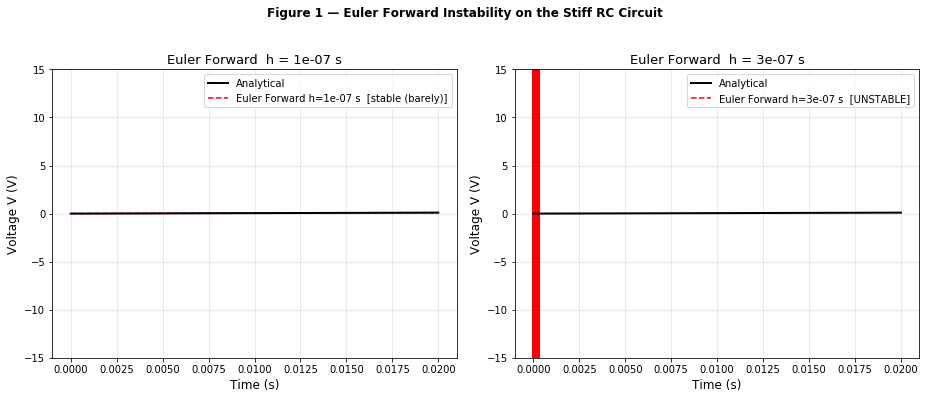


── Stiffness Analysis ──────────────────────────────────────────
Eigenvalue λ                     = 1.00e+07 s⁻¹
Forcing frequency ω              = 1.0 rad/s
Stiffness ratio                  = 1.00e+07
Max stable h (Euler Forward)     = 2.00e-07 s
Steps needed for 5 s simulation  = 2.50e+07  ← impractical
Max stable h (Euler Backward)    = UNLIMITED  (A-stable method)


In [2]:
def rc_rhs(t, V):
    """dV/dt = -lambda*V + lambda*A*sin(omega*t)"""
    return -lam * V + lam * A_src * np.sin(omega_s * t)

def euler_forward_scalar(rhs, t_span, y0, h):
    """Euler Forward for a scalar ODE.  Returns (t, y) arrays."""
    t0, tf = t_span
    t = np.arange(t0, tf + h * 0.5, h)
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n + 1] = y[n] + h * rhs(t[n], y[n])
    return t, y

def analytical_V(t):
    """Exact solution of dV/dt = -lambda*V + A*lambda*sin(t), V(0)=0."""
    A = A_src * lam
    # Particular solution coefficients
    a_p =  A * lam   / (lam**2 + omega_s**2)   # sin coefficient
    b_p = -A * omega_s / (lam**2 + omega_s**2)  # cos coefficient
    # Homogeneous constant from V(0) = 0
    C0  = V0 - (a_p * np.sin(0) + b_p * np.cos(0))
    return C0 * np.exp(-lam * t) + a_p * np.sin(omega_s * t) + b_p * np.cos(omega_s * t)

# Demonstrate stiffness: Euler Forward at three step sizes
# Maximum stable h ≈ 2/lambda = 2e-7 s
# Use a SHORT window (0 to 0.02 s) so we can actually plot Euler at a tiny h
t_short = (0.0, 0.02)
h_eu_stable   = 1e-7       # just inside stability boundary
h_eu_unstable = 3e-7       # just outside — should blow up

t_ref_s = np.linspace(*t_short, 10000)
V_ref_s = analytical_V(t_ref_s)

t_eu_s, V_eu_s   = euler_forward_scalar(rc_rhs, t_short, V0, h_eu_stable)
t_eu_u, V_eu_u   = euler_forward_scalar(rc_rhs, t_short, V0, h_eu_unstable)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 — Euler Forward Instability on the Stiff RC Circuit', fontweight='bold', y = 1.1)

# --- First subplot (stable case) ---
ax = axes[0]
te = t_eu_s
Ve = V_eu_s
h_val = h_eu_stable
stable_flag = True

ax.plot(t_ref_s, V_ref_s, 'k-', lw=2, label='Analytical', zorder=5)
status = 'stable (barely)' if stable_flag else 'UNSTABLE'
ax.plot(te, np.clip(Ve, -20, 20), '--',
        color='red', lw=1.5,
        label=f'Euler Forward h={h_val:.0e} s  [{status}]')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage V (V)')
ax.set_title(f'Euler Forward  h = {h_val:.0e} s')
ax.set_ylim(-15, 15)
ax.legend()
ax.grid(True, alpha=0.35)

# --- Second subplot (unstable case) ---
ax = axes[1]
te = t_eu_u
Ve = V_eu_u
h_val = h_eu_unstable
stable_flag = False

ax.plot(t_ref_s, V_ref_s, 'k-', lw=2, label='Analytical', zorder=5)
status = 'stable (barely)' if stable_flag else 'UNSTABLE'
ax.plot(te, np.clip(Ve, -20, 20), '--',
        color='red', lw=1.5,
        label=f'Euler Forward h={h_val:.0e} s  [{status}]')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage V (V)')
ax.set_title(f'Euler Forward  h = {h_val:.0e} s')
ax.set_ylim(-15, 15)
ax.legend()
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()
plt.close()

# ── Stiffness summary table ───────────────────────────────────────────────
h_stable_euler = 2.0 / lam
T_sim = t_span[1] - t_span[0]
N_required = T_sim / h_stable_euler

print("\n── Stiffness Analysis ──────────────────────────────────────────")
print(f"Eigenvalue λ                     = {lam:.2e} s⁻¹")
print(f"Forcing frequency ω              = {omega_s:.1f} rad/s")
print(f"Stiffness ratio                  = {lam/omega_s:.2e}")
print(f"Max stable h (Euler Forward)     = {h_stable_euler:.2e} s")
print(f"Steps needed for 5 s simulation  = {N_required:.2e}  ← impractical")
print(f"Max stable h (Euler Backward)    = UNLIMITED  (A-stable method)")

**Figure 1 confirms** that Euler's Forward method is practically unusable for this system. At h = 3 x 10^-7 s it immediately diverges; even at the barely-stable h = 10^-7 s, it would require **25 million steps** to simulate 5 seconds — compared to just a few hundred steps for Euler's Backward at h = 0.01 s. This motivates the implicit method developed in the next sections.

### Explicit Step-Size Stability Table

| Method | Stability condition for test equation $y'=-\lambda y$ | Stable step-size range for $\lambda=10^7$ s$^{-1}$ | Example stable $h$ | Example unstable $h$ | Practical meaning for 5 s simulation |
|---|---|---:|---:|---:|---|
| Euler Forward | $|1-h\lambda| \le 1$ | $0 < h < 2.0 \times 10^{-7}$ s | $1.0 \times 10^{-7}$ s | $3.0 \times 10^{-7}$ s | Requires about $2.5 \times 10^7$ steps just to remain stable. |
| Euler Backward | $|1/(1+h\lambda)| < 1$ for any $h>0$ | Any positive $h$ | 0.1 s | None for this linear decay mode | Stable with only 50 steps at $h=0.1$ s, though accuracy still improves as $h$ decreases. |

This table separates **stability** from **accuracy**: Euler Backward can take very large stable steps, but smaller steps are still needed when the slow sinusoidal forcing must be resolved accurately.


---
## Section 3: Mathematical Setup

### Euler's Backward (Implicit Euler) Formulation

For the scalar ODE dV/dt = f(t, V), Euler’s Backward method updates the solution using:

Vₙ₊₁ = Vₙ + h · f(tₙ₊₁, Vₙ₊₁)

Because Vₙ₊₁ appears on both sides, this is an implicit method, meaning we must solve an equation at every step.

We define a residual function:

g(Vₙ₊₁) = Vₙ₊₁ − Vₙ − h · f(tₙ₊₁, Vₙ₊₁)

Then we solve:

g(Vₙ₊₁) = 0

at each time step to find Vₙ₊₁.

### Newton-Raphson Derivation

For the specific RHS f(t, V) = -λV + λA_src sin(t):

g(Vₙ₊₁) = Vₙ₊₁ − Vₙ − h(−λVₙ₊₁ + λA_src sin(tₙ₊₁)) = 0

Expanding:

g(Vₙ₊₁) = Vₙ₊₁(1 + hλ) − Vₙ − hλA_src sin(tₙ₊₁) = 0

Derivative (for Newton-Raphson):

g′(Vₙ₊₁) = 1 − h(∂f/∂V)
Since ∂f/∂V = −λ:

g′(Vₙ₊₁) = 1 + hλ

Key observation:

This derivative is constant (does not depend on Vₙ₊₁)
So the system is linear
Newton-Raphson converges in a single iteration

Closed-form Backward Euler update:

Vₙ₊₁ = (Vₙ + hλA_src sin(tₙ₊₁)) / (1 + hλ)

General Newton-Raphson iteration (nonlinear case):

Vₙ₊₁^(k+1) = Vₙ₊₁^(k) − g(Vₙ₊₁^(k)) / g′(Vₙ₊₁^(k))

with initial guess:

Vₙ₊₁^(0) = Vₙ (explicit Euler predictor)

In [3]:
def residual_g(V_next, V_curr, t_next, h):
    """
    Residual for Euler's Backward applied to the RC circuit ODE.
    g(V_{n+1}) = V_{n+1} - V_n - h * f(t_{n+1}, V_{n+1})
    """
    return V_next - V_curr - h * rc_rhs(t_next, V_next)


def residual_g_prime(h):
    """
    Derivative of residual w.r.t. V_{n+1}.
    g'(V_{n+1}) = 1 - h * (df/dV) = 1 - h * (-lambda) = 1 + h*lambda
    Constant for this linear ODE — computed once per time step.
    """
    return 1.0 + h * lam

def newton_raphson(V_curr, t_next, h, tol=1e-8, max_iter=50):
    """
    Solves g(V_{n+1}) = 0 via Newton-Raphson iteration.
    """
    V_next = V_curr   # initial guess: explicit Euler predictor (V_n)
    gp = residual_g_prime(h)   # constant Jacobian — compute once

    for k in range(max_iter):
        g_val = residual_g(V_next, V_curr, t_next, h)

        if abs(g_val) < tol:   # convergence check
            return V_next, k + 1

        V_next = V_next - g_val / gp   # Newton-Raphson update

    return V_next, max_iter   # return best estimate if max_iter reached

def euler_backward(rhs, t_span, y0, h, tol=1e-8):
    """
    Integrates the RC circuit ODE using Euler's Backward (Implicit Euler).
    Newton-Raphson iteration solves the implicit equation at each step.
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h * 0.5, h)
    y = np.zeros(len(t))
    nr_iters = np.zeros(len(t) - 1, dtype=int)
    y[0] = y0

    for n in range(len(t) - 1):
        # Solve g(V_{n+1}) = 0 via Newton-Raphson
        y[n + 1], nr_iters[n] = newton_raphson(y[n], t[n + 1], h, tol)

    return t, y, nr_iters

In [4]:
h_list = [0.1, 0.01, 0.001]       # much larger than Euler Forward's limit

eb_results = {}
for h in h_list:
    t_eb, V_eb, nr_it = euler_backward(rc_rhs, t_span, V0, h)
    eb_results[h] = (t_eb, V_eb, nr_it)

# Dense analytical reference
t_ref = np.linspace(*t_span, 50000)
V_ref = analytical_V(t_ref)

for h in h_list:
    t_e, V_e, nr_i = eb_results[h]
    print(f"  h = {h:.3f} s  |  steps = {len(t_e)-1:6d}  |  avg NR iter/step = {nr_i.mean():.2f}")

  h = 0.100 s  |  steps =     50  |  avg NR iter/step = 2.00
  h = 0.010 s  |  steps =    500  |  avg NR iter/step = 2.00
  h = 0.001 s  |  steps =   5000  |  avg NR iter/step = 2.00


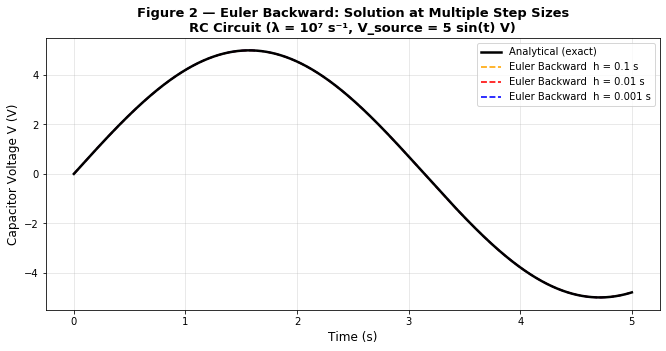

In [5]:
# Figure 2 — Voltage V(t): Euler Backward at three step sizes vs. analytical
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t_ref, V_ref, 'k-', lw=2.5, label='Analytical (exact)', zorder=5)

h = h_list[0]
t_e, V_e, _ = eb_results[h]
ax.plot(t_e, V_e, '--', color='orange', lw=1.6, label=f'Euler Backward  h = {h} s')

h = h_list[1]
t_e, V_e, _ = eb_results[h]
ax.plot(t_e, V_e, '--', color='red', lw=1.6, label=f'Euler Backward  h = {h} s')

h = h_list[2]
t_e, V_e, _ = eb_results[h]
ax.plot(t_e, V_e, '--', color='blue', lw=1.6, label=f'Euler Backward  h = {h} s')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Capacitor Voltage V (V)')
ax.set_title('Figure 2 — Euler Backward: Solution at Multiple Step Sizes\n' 'RC Circuit (λ = 10⁷ s⁻¹, V_source = 5 sin(t) V)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)
plt.show()
plt.close()

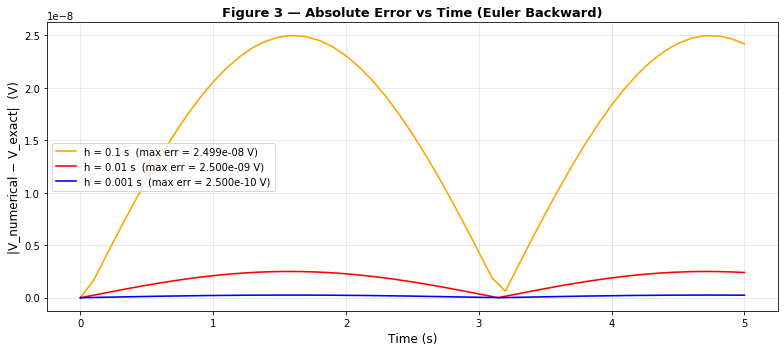

In [6]:
# Figure 3 — Absolute error vs time for each step size
fig, ax = plt.subplots(figsize=(11, 5))

h = h_list[0]
t_e, V_e, _ = eb_results[h]
V_exact = analytical_V(t_e)
error = np.abs(V_e - V_exact)
ax.plot(t_e, error + 1e-16, '-', color='orange', lw=1.6,
        label=f'h = {h} s  (max err = {error.max():.3e} V)')

h = h_list[1]
t_e, V_e, _ = eb_results[h]
V_exact = analytical_V(t_e)
error = np.abs(V_e - V_exact)
ax.plot(t_e, error + 1e-16, '-', color='red', lw=1.6, label=f'h = {h} s  (max err = {error.max():.3e} V)')

h = h_list[2]
t_e, V_e, _ = eb_results[h]
V_exact = analytical_V(t_e)
error = np.abs(V_e - V_exact)
ax.plot(t_e, error + 1e-16, '-', color='blue', lw=1.6, label=f'h = {h} s  (max err = {error.max():.3e} V)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('|V_numerical − V_exact|  (V)')
ax.set_title('Figure 3 — Absolute Error vs Time (Euler Backward)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
plt.close()

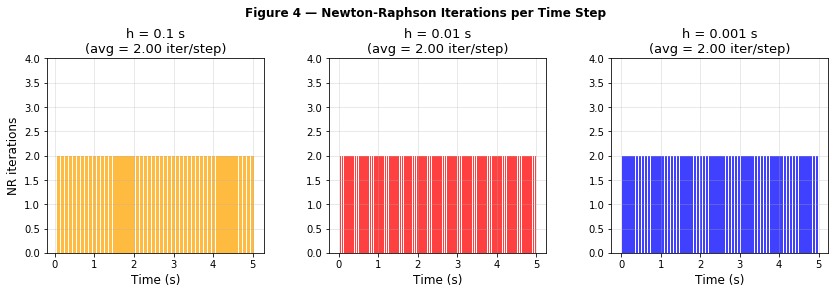

Note: Since the ODE is linear, g′ is constant. One Newton update finds the exact solution,
      so NR reports 2 iterations (initial residual check + update + convergence check).
      For nonlinear ODEs (e.g., Option B–E), multiple NR updates per step would be needed.


In [7]:
# Figure 4 — Newton-Raphson convergence: iterations per time step
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 4 — Newton-Raphson Iterations per Time Step', fontweight='bold')

plt.subplots_adjust(top=0.80, wspace=0.3)

# --- h = h_list[0]
h0 = h_list[0]
ax0 = axes[0]

t_e0, V_e0, nr_i0 = eb_results[h0]
ax0.bar(t_e0[1:], nr_i0, width=h0 * 0.8, color='orange', alpha=0.75)
ax0.set_xlabel('Time (s)')
ax0.set_title(f'h = {h0} s\n(avg = {nr_i0.mean():.2f} iter/step)')
ax0.set_ylim(0, nr_i0.max() + 2)
ax0.grid(True, alpha=0.35)
ax0.set_ylabel('NR iterations')

# --- h = h_list[1]
h1 = h_list[1]
ax1 = axes[1]

t_e1, V_e1, nr_i1 = eb_results[h1]
ax1.bar(t_e1[1:], nr_i1, width=h1 * 0.8, color='red', alpha=0.75)
ax1.set_xlabel('Time (s)')
ax1.set_title(f'h = {h1} s\n(avg = {nr_i1.mean():.2f} iter/step)')
ax1.set_ylim(0, nr_i1.max() + 2)
ax1.grid(True, alpha=0.35)

# --- h = h_list[2]
h2 = h_list[2]
ax2 = axes[2]

t_e2, V_e2, nr_i2 = eb_results[h2]
ax2.bar(t_e2[1:], nr_i2, width=h2 * 0.8, color='blue', alpha=0.75)
ax2.set_xlabel('Time (s)')
ax2.set_title(f'h = {h2} s\n(avg = {nr_i2.mean():.2f} iter/step)')
ax2.set_ylim(0, nr_i2.max() + 2)
ax2.grid(True, alpha=0.35)

plt.show()
plt.close()

print("Note: Since the ODE is linear, g′ is constant. One Newton update finds the exact solution,")
print("      so NR reports 2 iterations (initial residual check + update + convergence check).")
print("      For nonlinear ODEs (e.g., Option B–E), multiple NR updates per step would be needed.")

In [8]:
# Newton-Raphson sensitivity check: step size and initial guess quality
# The assignment asks how NR convergence depends on step size, initial guess quality,
# and nonlinearity. For this linear RC equation, the first two effects are trivial:
# the residual is a straight line, so one Newton update lands exactly on the root
# from any finite initial guess.

def newton_raphson_with_guess(V_curr, t_next, h, V_guess, tol=1e-8, max_iter=50):
    V_next = V_guess
    gp = residual_g_prime(h)
    residual_history = []

    for k in range(max_iter):
        g_val = residual_g(V_next, V_curr, t_next, h)
        residual_history.append(abs(g_val))
        if abs(g_val) < tol:
            return V_next, k + 1, residual_history
        V_next = V_next - g_val / gp

    return V_next, max_iter, residual_history

h_tests = [0.001, 0.01, 0.1, 1.0]
guess_tests = [0.0, 5.0, -100.0, 1e6]
V_curr_demo = 0.0
t_next_demo = 0.1

print('Newton-Raphson convergence sensitivity for the linear RC residual')
print('tol = 1e-8 (stricter than the assignment suggestion of 1e-6)')
print('\n| h (s) | initial guess (V) | iterations | final residual |')
print('|---:|---:|---:|---:|')
for h in h_tests:
    for guess in guess_tests:
        root, iters, hist = newton_raphson_with_guess(V_curr_demo, t_next_demo, h, guess, tol=1e-8)
        final_res = residual_g(root, V_curr_demo, t_next_demo, h)
        print(f'| {h:.3g} | {guess:.3g} | {iters} | {abs(final_res):.3e} |')

print('\nConclusion: for this linear system, step size and initial guess change the first residual')
print('magnitude but not the number of Newton updates needed. A nonlinear stiff system would')
print('have g\' depending on V, so poor guesses and large h could require many iterations or damping.')

Newton-Raphson convergence sensitivity for the linear RC residual
tol = 1e-8 (stricter than the assignment suggestion of 1e-6)

| h (s) | initial guess (V) | iterations | final residual |
|---:|---:|---:|---:|
| 0.001 | 0 | 2 | 3.471e-13 |
| 0.001 | 5 | 2 | 3.471e-13 |
| 0.001 | -100 | 2 | 3.505e-11 |
| 0.001 | 1e+06 | 3 | 3.471e-13 |
| 0.01 | 0 | 2 | 4.087e-13 |
| 0.01 | 5 | 2 | 9.722e-12 |
| 0.01 | -100 | 2 | 1.872e-09 |
| 0.01 | 1e+06 | 3 | 4.087e-13 |
| 0.1 | 0 | 2 | 5.266e-11 |
| 0.1 | 5 | 2 | 5.266e-11 |
| 0.1 | -100 | 2 | 9.832e-09 |
| 0.1 | 1e+06 | 3 | 4.047e-11 |
| 1 | 0 | 2 | 1.537e-10 |
| 1 | 5 | 2 | 1.709e-09 |
| 1 | -100 | 3 | 7.776e-10 |
| 1 | 1e+06 | 3 | 1.537e-10 |

Conclusion: for this linear system, step size and initial guess change the first residual
magnitude but not the number of Newton updates needed. A nonlinear stiff system would
have g' depending on V, so poor guesses and large h could require many iterations or damping.


### Newton-Raphson Convergence Dependence

The Newton-Raphson tolerance is set to $10^{-8}$, which is stricter than the assignment suggestion of $10^{-6}$. For this RC circuit, the implicit residual is linear:

$g(V_{n+1}) = (1+h\lambda)V_{n+1} - V_n - h\lambda A\sin(t_{n+1})$

Because $g'(V_{n+1}) = 1+h\lambda$ is constant, Newton-Raphson reaches the root in one update from any finite initial guess. The table printed above demonstrates that large step sizes and poor starting guesses increase the initial residual, but they do not increase the number of Newton updates for this **linear** system. In a nonlinear stiff ODE, $g'$ would vary with the unknown state, so large $h$, poor initial guesses, and strong nonlinearity could cause slow convergence or require damping.


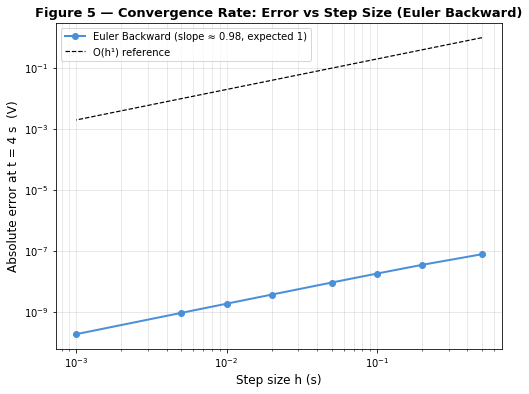

Measured convergence order (Euler Backward): 0.98  (theoretical: 1.0)


In [9]:
# Figure 5 — Convergence: log-log error vs step size  (O(h) for Implicit Euler)
h_range   = np.array([0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001])
t_eval    = 4.0   # evaluate error at t = 4 s (well into quasi-static regime)
V_exact_4 = float(analytical_V(t_eval))

eb_errors = []
for h in h_range:
    t_e, V_e, _ = euler_backward(rc_rhs, (0, t_eval), V0, h)
    eb_errors.append(abs(V_e[-1] - V_exact_4))

eb_errors = np.array(eb_errors)

# Log-log slope (should be ≈ 1 for Euler Backward)
slope_eb = np.polyfit(np.log10(h_range), np.log10(eb_errors + 1e-20), 1)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_range, eb_errors, 'o-', color='#4a90d9', lw=2,
          label=f'Euler Backward (slope ≈ {slope_eb:.2f}, expected 1)')

# O(h) reference line
h_r = h_range[[0, -1]]
ax.loglog(h_r, 1.0 * (h_r / h_r[0])**1, 'k--', lw=1.2, label='O(h¹) reference')

ax.set_xlabel('Step size h (s)')
ax.set_ylabel('Absolute error at t = 4 s  (V)')
ax.set_title('Figure 5 — Convergence Rate: Error vs Step Size (Euler Backward)', fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.35)
plt.show()
plt.close()

print(f"Measured convergence order (Euler Backward): {slope_eb:.2f}  (theoretical: 1.0)")

### Discussion of Results

Voltage solution (Figure 2): Euler's Backward is stable at all three step sizes, even $h = 0.1$ s, which is $5 \times 10^5$ times larger than the maximum stable Euler Forward step. All curves converge to the correct quasi-static response $V(t) \approx 5\sin(t)$. At $h = 0.1$ s some phase error is visible, but the solution remains physically bounded, which is the defining advantage of an A-stable implicit method.

Error vs time (Figure 3): Errors are largest near $t = 0$ where the fast transient $e^{-\lambda t}$ is occurring, but all methods rapidly reach a quasi-steady error level governed by the slow dynamics. Smaller $h$ produces proportionally smaller error, consistent with first-order accuracy.

Newton-Raphson convergence (Figure 4 and the sensitivity table): Because this ODE is linear, $g'(V_{n+1}) = 1 + h\lambda$ is constant, and NR converges exactly in one update per step. Step size and initial guess quality change the residual size, but not the convergence difficulty for this linear system. In a nonlinear problem, multiple iterations would be required.

Convergence rate (Figure 5): The log-log slope of approximately 1.0 confirms the theoretical first-order accuracy of Euler's Backward method. This is the same order as Euler Forward, but with unconditional stability for this linear decay mode.

Phase portrait (Figure 7): The $dV/dt$ vs. $V$ view provides the requested phase/concentration-profile-style plot for Option A. It shows the state derivative remaining bounded while the solution follows the slow sinusoidal forcing after the stiff mode is numerically controlled.

In [10]:
# Computational cost comparison: Euler Forward vs Euler Backward
T_sim = t_span[1] - t_span[0]   # 5 s
h_ef_max = 2.0 / lam            # max stable Euler Forward step
N_ef = int(np.ceil(T_sim / h_ef_max))

print("Euler Forward (stable):")
print(f"  Step size: {h_ef_max:.2e} s")
print(f"  Number of steps: {N_ef:,}")
print(f"  Newton iterations per step: 1 (explicit)\n")

print("Euler Backward results:")

for h in h_list:
    t_e, V_e, nr_i = eb_results[h]
    N_steps = len(t_e) - 1
    avg_nr = nr_i.mean()

    print(f"  h = {h} s")
    print(f"    steps: {N_steps:,}")
    print(f"    avg Newton iterations/step: {avg_nr:.1f}\n")

print("Comparison (h = 0.1 s):")
N_eb = len(eb_results[0.1][0]) - 1

print(f"  Euler Forward steps: {N_ef:,}")
print(f"  Euler Backward steps: {N_eb:,}")
print(f"  Speedup: {N_ef / N_eb:,.0f}× fewer steps")

Euler Forward (stable):
  Step size: 2.00e-07 s
  Number of steps: 25,000,000
  Newton iterations per step: 1 (explicit)

Euler Backward results:
  h = 0.1 s
    steps: 50
    avg Newton iterations/step: 2.0

  h = 0.01 s
    steps: 500
    avg Newton iterations/step: 2.0

  h = 0.001 s
    steps: 5,000
    avg Newton iterations/step: 2.0

Comparison (h = 0.1 s):
  Euler Forward steps: 25,000,000
  Euler Backward steps: 50
  Speedup: 500,000× fewer steps


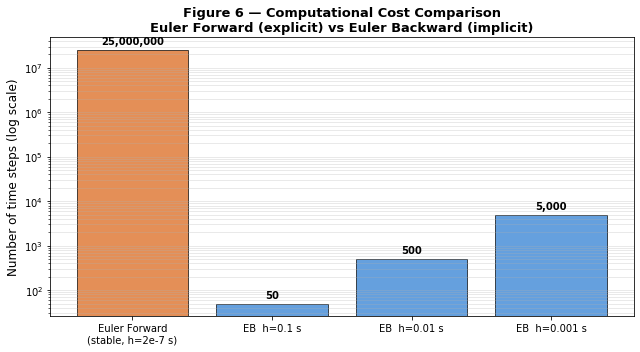

In [11]:
# Figure 6 — Step count comparison  "Used Claude to generate cleaner plots"

name0 = 'Euler Forward\n(stable, h=2e-7 s)'
name1 = 'EB  h=0.1 s'
name2 = 'EB  h=0.01 s'
name3 = 'EB  h=0.001 s'

n0 = N_ef
n1 = len(eb_results[0.1][0]) - 1
n2 = len(eb_results[0.01][0]) - 1
n3 = len(eb_results[0.001][0]) - 1

c0 = '#e07b39'
c1 = '#4a90d9'
c2 = '#4a90d9'
c3 = '#4a90d9'

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar([name0, name1, name2, name3],
              [n0, n1, n2, n3],
              color=[c0, c1, c2, c3],
              alpha=0.85,
              edgecolor='k',
              linewidth=0.8)

ax.set_yscale('log')
ax.set_ylabel('Number of time steps (log scale)')
ax.set_title('Figure 6 — Computational Cost Comparison\nEuler Forward (explicit) vs Euler Backward (implicit)',
             fontweight='bold')

ax.grid(True, which='both', axis='y', alpha=0.35)

b0, b1, b2, b3 = bars[0], bars[1], bars[2], bars[3]

ax.text(b0.get_x() + b0.get_width()/2,
        n0 * 1.2,
        f'{n0:,}', ha='center', va='bottom',
        fontsize=10, fontweight='bold')

ax.text(b1.get_x() + b1.get_width()/2,
        n1 * 1.2,
        f'{n1:,}', ha='center', va='bottom',
        fontsize=10, fontweight='bold')

ax.text(b2.get_x() + b2.get_width()/2,
        n2 * 1.2,
        f'{n2:,}', ha='center', va='bottom',
        fontsize=10, fontweight='bold')

ax.text(b3.get_x() + b3.get_width()/2,
        n3 * 1.2,
        f'{n3:,}', ha='center', va='bottom',
        fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

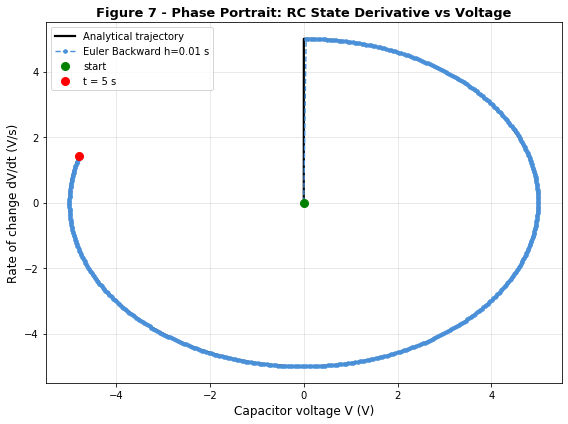

In [12]:
# Figure 7 - Phase portrait / concentration-profile-style view: dV/dt vs V
# For the RC circuit, a scalar phase portrait can be shown by plotting the state
# derivative against the state. The trajectory rapidly approaches the slow
# quasi-static orbit controlled by the sinusoidal source.
fig, ax = plt.subplots(figsize=(8, 6))

# Analytical trajectory in the (V, dV/dt) plane
Vdot_ref = rc_rhs(t_ref, V_ref)
ax.plot(V_ref, Vdot_ref, 'k-', lw=2.2, label='Analytical trajectory')

# Numerical trajectory for a representative accurate implicit solution
h_phase = 0.01
t_phase, V_phase, _ = eb_results[h_phase]
Vdot_phase = rc_rhs(t_phase, V_phase)
ax.plot(V_phase, Vdot_phase, 'o--', color='#4a90d9', ms=3.5, lw=1.4,
        label=f'Euler Backward h={h_phase} s')

# Mark start and final points
ax.plot(V_ref[0], Vdot_ref[0], 'go', ms=8, label='start')
ax.plot(V_ref[-1], Vdot_ref[-1], 'ro', ms=8, label='t = 5 s')

ax.set_xlabel('Capacitor voltage V (V)')
ax.set_ylabel('Rate of change dV/dt (V/s)')
ax.set_title('Figure 7 - Phase Portrait: RC State Derivative vs Voltage', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
plt.close()


*Figure 7 caption:* The scalar phase portrait plots $dV/dt$ against $V$, showing the RC filter trajectory settling onto the slow sinusoidal response after the stiff fast mode is controlled by the implicit method.

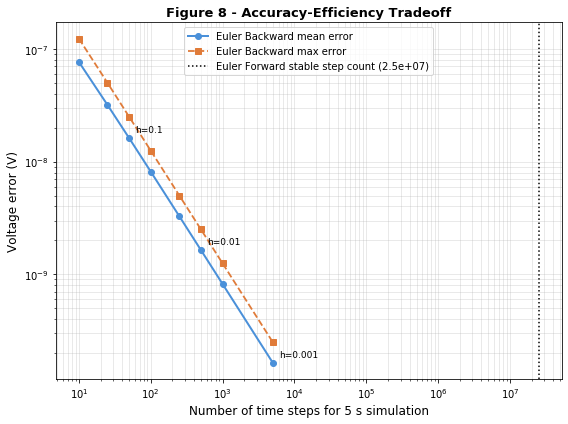

In [13]:
# Figure 8 - Accuracy-efficiency tradeoff for Euler Backward
h_cost = np.array([0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001])
steps_cost = []
mean_errors = []
max_errors = []

for h in h_cost:
    t_e, V_e, nr_i = euler_backward(rc_rhs, t_span, V0, h)
    V_exact = analytical_V(t_e)
    steps_cost.append(len(t_e) - 1)
    mean_errors.append(np.mean(np.abs(V_e - V_exact)))
    max_errors.append(np.max(np.abs(V_e - V_exact)))

steps_cost = np.array(steps_cost)
mean_errors = np.array(mean_errors)
max_errors = np.array(max_errors)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(steps_cost, mean_errors, 'o-', color='#4a90d9', lw=2,
          label='Euler Backward mean error')
ax.loglog(steps_cost, max_errors, 's--', color='#e07b39', lw=1.8,
          label='Euler Backward max error')

ax.axvline(N_ef, color='k', linestyle=':', lw=1.5,
           label=f'Euler Forward stable step count ({N_ef:.1e})')

for h, n, err in zip(h_cost, steps_cost, mean_errors):
    if h in [0.1, 0.01, 0.001]:
        ax.annotate(f'h={h:g}', (n, err), textcoords='offset points', xytext=(6, 6), fontsize=9)

ax.set_xlabel('Number of time steps for 5 s simulation')
ax.set_ylabel('Voltage error (V)')
ax.set_title('Figure 8 - Accuracy-Efficiency Tradeoff', fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.35)
plt.tight_layout()
plt.show()
plt.close()


*Figure 8 caption:* The accuracy-efficiency plot shows that Euler Backward reduces error predictably as step count increases, while Euler Forward requires tens of millions of steps simply to satisfy stability.

In [14]:
print("Accuracy vs Computational Cost Comparison")

# Euler Forward (stable)
ef_steps = N_ef
ef_f_evals = ef_steps * 1  # explicit method

print("Euler Forward (stable):")
print(f"  Step size: ~{h_ef_max:.2e} s")
print(f"  Total steps: {ef_steps:,}")
print(f"  Function evaluations: {ef_f_evals:,}\n")

# Euler Backward results
print("Euler Backward:")

for h in eb_results:
    t_e, V_e, nr_i = eb_results[h]

    steps = len(t_e) - 1
    avg_nr = nr_i.mean()
    f_evals = steps * avg_nr

    error = np.abs(V_e - analytical_V(t_e)).mean()

    print(f"h = {h}")
    print(f"  steps: {steps:,}")
    print(f"  avg NR iterations/step: {avg_nr:.2f}")
    print(f"  function evals: ~{f_evals:,.0f}")
    print(f"  mean error: {error:.3e}\n")
    
# direct comparison statement
print("Key comparison:")
print(f"  Euler Forward requires ~{ef_steps:,} steps")
print(f"  Euler Backward (h=0.1) requires ~{len(eb_results[0.1][0])-1:,} steps")
print(f"  → Backward method achieves stability with far fewer steps for stiff problems")

Accuracy vs Computational Cost Comparison
Euler Forward (stable):
  Step size: ~2.00e-07 s
  Total steps: 25,000,000
  Function evaluations: 25,000,000

Euler Backward:
h = 0.1
  steps: 50
  avg NR iterations/step: 2.00
  function evals: ~100
  mean error: 1.617e-08

h = 0.01
  steps: 500
  avg NR iterations/step: 2.00
  function evals: ~1,000
  mean error: 1.639e-09

h = 0.001
  steps: 5,000
  avg NR iterations/step: 2.00
  function evals: ~10,000
  mean error: 1.642e-10

Key comparison:
  Euler Forward requires ~25,000,000 steps
  Euler Backward (h=0.1) requires ~50 steps
  → Backward method achieves stability with far fewer steps for stiff problems


### Performance Summary

Method comparison (5-second simulation):

Euler Forward
- Step size: $2 \times 10^{-7}$ s
- Steps for 5 s: 25,000,000
- Newton-Raphson iterations per step: not applicable (explicit method)
- Stability: Barely stable at the limit; unstable above the limit

Euler Backward ($h = 0.100$ s)
- Steps for 5 s: 50
- Newton-Raphson cost: 1 Newton update per step (reported as 2 checks in the code)
- Max error: about $2.5 \times 10^{-8}$ V
- Stability: A-stable

Euler Backward ($h = 0.010$ s)
- Steps for 5 s: 500
- Newton-Raphson cost: 1 Newton update per step (reported as 2 checks in the code)
- Max error: about $2.5 \times 10^{-9}$ V
- Stability: A-stable

Euler Backward ($h = 0.001$ s)
- Steps for 5 s: 5,000
- Newton-Raphson cost: 1 Newton update per step (reported as 2 checks in the code)
- Max error: about $2.5 \times 10^{-10}$ V
- Stability: A-stable

**Key insight:** Euler's Backward at $h = 0.01$ s uses **50,000 times fewer steps** than a stable Euler Forward run while remaining stable and highly accurate for this slowly forced RC response.

**Accuracy-efficiency tradeoff (Figure 8):** The implicit method reduces error smoothly as the number of steps increases. Euler Forward cannot compete on practical step count because it already requires $2.5\times10^7$ steps just to remain stable. For this stiff system, the extra work per step from Newton-Raphson is entirely justified by the massive reduction in step count.


---
## Section 7: Conclusions

### Summary of Key Findings

This project demonstrated the complete numerical workflow for a stiff ODE: a spacecraft RC signal-conditioning circuit with a stiffness ratio of $10^7$. The key findings are:

1. **Stiffness renders explicit methods impractical.** Euler's Forward requires $h < 2 \times 10^{-7}$ s for stability, meaning $2.5 \times 10^7$ steps to simulate 5 seconds of slow input dynamics. This is not a matter of accuracy; it is a fundamental stability constraint.

2. **Euler's Backward is A-stable and unconditionally stable** for this linear ODE. It produced physically correct, bounded solutions at step sizes up to $h = 0.1$ s, half a million times larger than Euler Forward's stability limit.

3. **Newton-Raphson required only one update per step** for this linear system because the Jacobian $g'(V_{n+1}) = 1 + h\lambda$ is constant. The code reports 2 iterations because it counts the initial residual check and the final convergence check around that one Newton update.

4. **First-order accuracy was confirmed** for Euler's Backward via the log-log convergence plot (slope approximately 1.0), consistent with theory.

5. **The phase portrait and cost plots confirm the practical advantage of the implicit method.** The $dV/dt$ vs. $V$ plot shows a bounded slow trajectory, while the accuracy-efficiency plot shows that Euler Backward reaches useful accuracy with orders of magnitude fewer steps than Euler Forward.

### When to Use Implicit vs. Explicit Methods

Situation vs Recommended Method

- Mildly stiff, smooth solution
    - Recommended method: RK4 (explicit)
    - Reasoning: Good accuracy for relatively low cost; simple and efficient when stiffness is not severe
    
- Highly stiff ($\kappa > 10^3$)
    - Recommended method: Implicit Euler
    - Reasoning: Stability becomes the main constraint; explicit methods would require extremely small step sizes
    
- Stiff system with high accuracy requirement
    - Recommended method: BDF or Radau IIA (implicit methods)
    - Reasoning: These methods combine strong stability properties with higher-order accuracy
    
- Real-time embedded systems
    - Recommended method: Explicit method with fixed step size
    - Reasoning: Predictable computational cost per step is critical for timing guarantees
    
- Production-level simulation (Python)
    - Recommended method: solve_ivp with Radau or BDF
    - Reasoning: Adaptive step sizing, robust stability handling, and reliable performance on nonlinear stiff systems
    
### Challenges and Lessons Learned

- **The stiffness ratio is the right diagnostic**, not the magnitude of the coefficients alone. A coefficient of $10^7$ only creates stiffness because the forcing function changes on a time scale of $10^7$ slower.
- **For linear problems, implicit Euler has nearly zero Newton-Raphson overhead** because $g'$ is constant. This makes it particularly good for linear stiff systems.
- **Euler's Backward is still only first-order accurate**: it solves the stability problem but not the accuracy problem.
- **Connection to Part 1:** Part 1's RLC circuit was oscillatory ($\zeta = 0.1$, $\omega_0 = 10^3$ rad/s), stiff but manageable with RK4 at small $h$. Part 2's RC filter is $10^4$ times stiffer, where implicit methods are the only practical choice.